#### `Article Followed:` https://medium.com/@ultimateabhi/visualizing-convolutional-neural-networks-9b06543c09bf

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
from torchvision.models import vgg16, resnet50, googlenet

In [2]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Helper Functions
def load_image(path, size=224):
    image = Image.open(path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0).to(device), image

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    return tensor * std + mean

def show_image(tensor, title=None, cmap=None):
    image = tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    image = np.clip(image, 0, 1)
    plt.imshow(image, cmap=cmap)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()




# Guided Backpropagation 
class GuidedBackprop:
    def __init__(self, model):
        self.model = model.eval()
        self.handlers = []
        self._register_hooks()

    def _register_hooks(self):
        def hook_fn(module, grad_in, grad_out):
            return tuple(torch.clamp(g, min=0.0) for g in grad_in)

        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                self.handlers.append(module.register_backward_hook(hook_fn))

    def generate(self, input_image):
        input_image.requires_grad = True
        output = self.model(input_image)
        class_idx = torch.argmax(output)
        output[0, class_idx].backward()
        return input_image.grad[0].cpu().numpy()

    def remove_hooks(self):
        for handle in self.handlers:
            handle.remove()
            
           
           
           
            
# Activation Maximization
class ActivationMaximizer:
    def __init__(self, model, layer, filter_idx, act_wt=1.0):
        self.model = model
        self.layer = layer
        self.filter_idx = filter_idx
        self.activation = None
        self.act_wt = act_wt
        self.register_hook()
    
    def register_hook(self):
        def forward_hook(module, input, output):
            self.activation = output
        
        self.hook = self.layer.register_forward_hook(forward_hook)
    
    def generate(self, size=224, lr=0.1, epochs=300):
        input_img = torch.randn(1, 3, size, size, device=device, requires_grad=True)
        optimizer = optim.Adam([input_img], lr=lr)

        for epoch in range(epochs):
            optimizer.zero_grad()
            self.model(input_img)

            act = self.activation[0, self.filter_idx]

            rms = torch.sqrt(torch.mean(act ** 2))
            pxl_inty = torch.sqrt(torch.mean(input_img ** 2))

            dx = input_img[:, :, 1:, :] - input_img[:, :, :-1, :]
            dy = input_img[:, :, :, 1:] - input_img[:, :, :, :-1]
            im_grd = torch.sqrt(torch.mean(dx ** 2) + torch.mean(dy ** 2))

            loss = -self.act_wt * rms + pxl_inty + im_grd

            loss.backward()
            optimizer.step()

            if epoch % 50 == 0:
                print(f"Epoch {epoch}/{epochs} | Loss: {loss.item():.4f}")
        
        result = denormalize(input_img).clamp(0, 1)
        return result.squeeze(0)





# Grad-CAM
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.register_hooks()
    
    def register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        
        self.forward_hook = self.target_layer.register_forward_hook(forward_hook)
        self.backward_hook = self.target_layer.register_backward_hook(backward_hook)
    
    def compute_cam(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        target = torch.zeros_like(output)
        target[0, class_idx] = 1
        output.backward(gradient=target)

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        weighted_activations = self.activations * pooled_gradients.view(1, -1, 1, 1)
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap.detach().cpu().numpy()
    
    
    

    
class VGG16Conv(nn.Module):
    def __init__(self):
        super(VGG16Conv, self).__init__()
        vgg = vgg16(pretrained=True)  # <-- changed name here
        self.features = vgg.features
        self.feature_maps = {}
        self.pool_locs = {}

    def forward(self, x):
        for idx, layer in enumerate(self.features):
            if isinstance(layer, nn.MaxPool2d):
                x, indices = F.max_pool2d(x, kernel_size=2, stride=2, return_indices=True)
                self.feature_maps[idx] = x
                self.pool_locs[idx] = indices
            else:
                x = layer(x)
                self.feature_maps[idx] = x
        return x

class VGG16Deconv(nn.Module):
    def __init__(self):
        super(VGG16Deconv, self).__init__()
        vgg = vgg16(pretrained=True)  # <-- fixed name clash
        self.features = list(vgg.features)
    
    def forward(self, feat_map, layer_idx, filter_idx, pool_locs):
        x = feat_map
        for idx in reversed(range(layer_idx + 1)):
            layer = self.features[idx]
            if isinstance(layer, nn.ReLU):
                x = F.relu(x)
            elif isinstance(layer, nn.Conv2d):
                x = F.conv_transpose2d(x, layer.weight.to(x.device), stride=layer.stride, padding=layer.padding)
            elif isinstance(layer, nn.MaxPool2d):
                x = F.max_unpool2d(x, pool_locs[idx], kernel_size=2, stride=2)
        return x

def visualize_deconv_layer(layer, vgg_conv, vgg_deconv):
    feat_map = vgg_conv.feature_maps[layer].clone()
    num_channels = feat_map.shape[1]
    
    # Find max activation channel
    activations = [torch.max(feat_map[0, i]).item() for i in range(num_channels)]
    best_idx = np.argmax(activations)
    
    # Zero out all other channels
    mask = torch.zeros_like(feat_map)
    mask[0, best_idx] = torch.where(
        feat_map[0, best_idx] == torch.max(feat_map[0, best_idx]),
        feat_map[0, best_idx],
        torch.tensor(0.0, device=feat_map.device)
    )
    
    print(f"Layer {layer} - Filter {best_idx} - Max Activation: {torch.max(feat_map[0, best_idx]).item()}")
    
    recon = vgg_deconv(mask, layer, best_idx, vgg_conv.pool_locs)
    recon = recon.data.cpu().numpy()[0].transpose(1, 2, 0)
    recon = (recon - recon.min()) / (recon.max() - recon.min() + 1e-8)
    recon = (recon * 255).astype(np.uint8)
    
    return recon

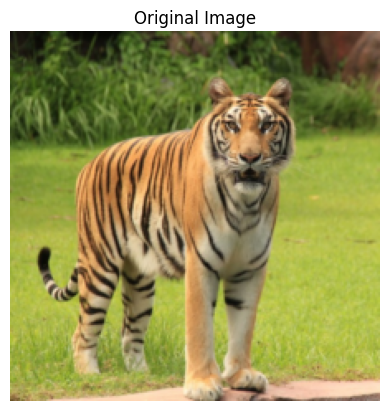

In [3]:
# Load image
input_tensor, input_pil = load_image("tiger.jpg")
denorm_image = denormalize(input_tensor).clamp(0, 1)
show_image(denorm_image, "Original Image")

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\module.py:1053: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full

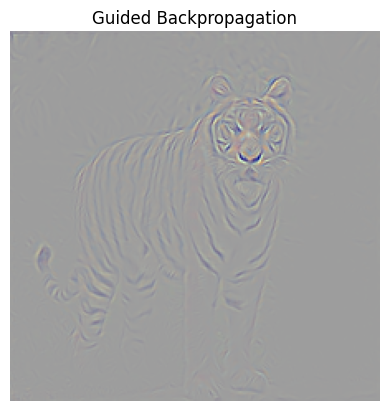

In [4]:

# === Guided Backpropagation ===
model = resnet50(pretrained=True).to(device).eval()
gbp = GuidedBackprop(model)
grad = gbp.generate(input_tensor)
sal_map = np.transpose(grad, (1, 2, 0))
sal_map = (sal_map - sal_map.min()) / (sal_map.max() - sal_map.min())
plt.imshow(sal_map)
plt.axis("off")
plt.title("Guided Backpropagation")
plt.show()

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0/1000 | Loss: 2.6102
Epoch 50/1000 | Loss: -4.4074
Epoch 100/1000 | Loss: -6.0429
Epoch 150/1000 | Loss: -7.2074
Epoch 200/1000 | Loss: -8.2413
Epoch 250/1000 | Loss: -9.3282
Epoch 300/1000 | Loss: -10.4562
Epoch 350/1000 | Loss: -11.6096
Epoch 400/1000 | Loss: -12.7298
Epoch 450/1000 | Loss: -13.8663
Epoch 500/1000 | Loss: -15.0513
Epoch 550/1000 | Loss: -16.2639
Epoch 600/1000 | Loss: -17.4748
Epoch 650/1000 | Loss: -18.6975
Epoch 700/1000 | Loss: -19.9560
Epoch 750/1000 | Loss: -21.2254
Epoch 800/1000 | Loss: -22.5548
Epoch 850/1000 | Loss: -23.9257
Epoch 900/1000 | Loss: -25.2945
Epoch 950/1000 | Loss: -26.6700


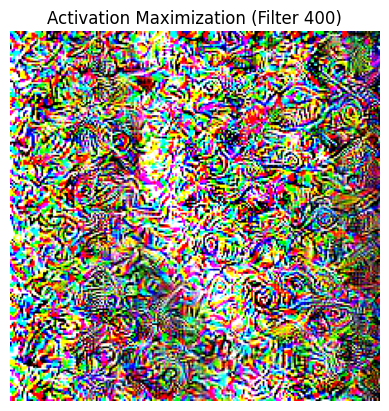

In [5]:
# === Activation Maximization ===
model = googlenet(pretrained=True).to(device).eval()
target_layer = model.inception4a 
filter_idx = 400
act_wt = 1.0  # Weight of activation relative to penalties
act_max = ActivationMaximizer(model, target_layer, filter_idx, act_wt=act_wt)
max_act_img = act_max.generate(size=224, lr=0.1, epochs=1000)
show_image(max_act_img, f"Activation Maximization (Filter {filter_idx})")

In [6]:
'''
from torchvision.models import vgg16
import torch

# === Activation Maximization for VGG16 ===
model = vgg16(pretrained=True).to(device).eval()

# Select a layer from vgg16.features (e.g., 28 is one of the last conv layers)
target_layer = model.features[28]  # You can change the index to any conv layer
filter_idx = 200  # Adjust based on how many filters the layer has
act_wt = 1.0  # Weight of activation relative to penalties

# Assume ActivationMaximizer is already defined and compatible
act_max = ActivationMaximizer(model, target_layer, filter_idx, act_wt=act_wt)
max_act_img = act_max.generate(size=224, lr=0.1, epochs=500)

# Display the resulting image
show_image(max_act_img, f"Activation Maximization (VGG16 - Filter {filter_idx})")
'''

'\nfrom torchvision.models import vgg16\nimport torch\n\n# === Activation Maximization for VGG16 ===\nmodel = vgg16(pretrained=True).to(device).eval()\n\n# Select a layer from vgg16.features (e.g., 28 is one of the last conv layers)\ntarget_layer = model.features[28]  # You can change the index to any conv layer\nfilter_idx = 200  # Adjust based on how many filters the layer has\nact_wt = 1.0  # Weight of activation relative to penalties\n\n# Assume ActivationMaximizer is already defined and compatible\nact_max = ActivationMaximizer(model, target_layer, filter_idx, act_wt=act_wt)\nmax_act_img = act_max.generate(size=224, lr=0.1, epochs=500)\n\n# Display the resulting image\nshow_image(max_act_img, f"Activation Maximization (VGG16 - Filter {filter_idx})")\n'

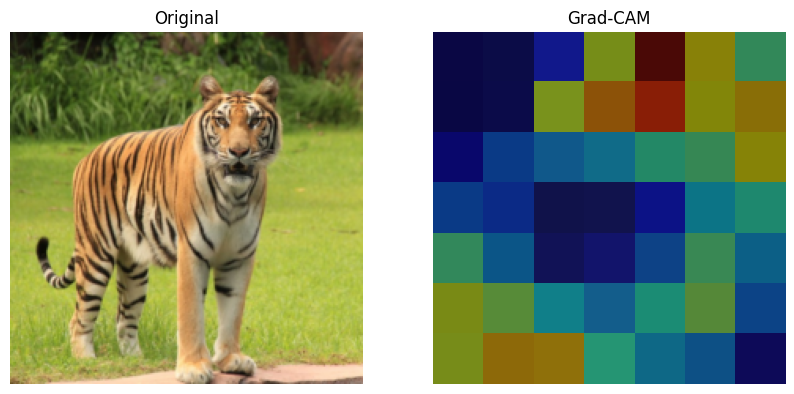

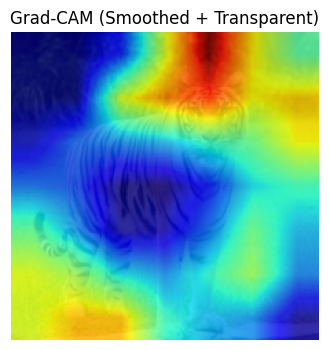

In [7]:
# === Grad-CAM ===
model = resnet50(pretrained=True).to(device).eval()
target_layer = model.layer4[2].conv3
gradcam = GradCAM(model, target_layer)
heatmap = gradcam.compute_cam(input_tensor)

# Overlay heatmap on original image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(denorm_image.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(denorm_image.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

# Original image (already denormalized)
original = denorm_image.squeeze(0).permute(1, 2, 0).cpu().numpy()

# Normalize and smooth heatmap
#heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
#heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)

# Resize heatmap to match image
heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))

# Display overlay with lower alpha
plt.figure(figsize=(8, 4))
plt.imshow(original)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.8)  # Transparent overlay
plt.axis('off')
plt.title("Grad-CAM (Smoothed + Transparent)")
plt.show()

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Layer 14 - Filter 14 - Max Activation: 81.95706939697266
Layer 17 - Filter 162 - Max Activation: 77.82217407226562
Layer 19 - Filter 289 - Max Activation: 68.81124877929688
Layer 21 - Filter 50 - Max Activation: 56.08141326904297
Layer 24 - Filter 351 - Max Activation: 64.55502319335938
Layer 26 - Filter 316 - Max Activation: 39.45021438598633
Layer 28 - Filter 413 - Max Activation: 31.99824333190918


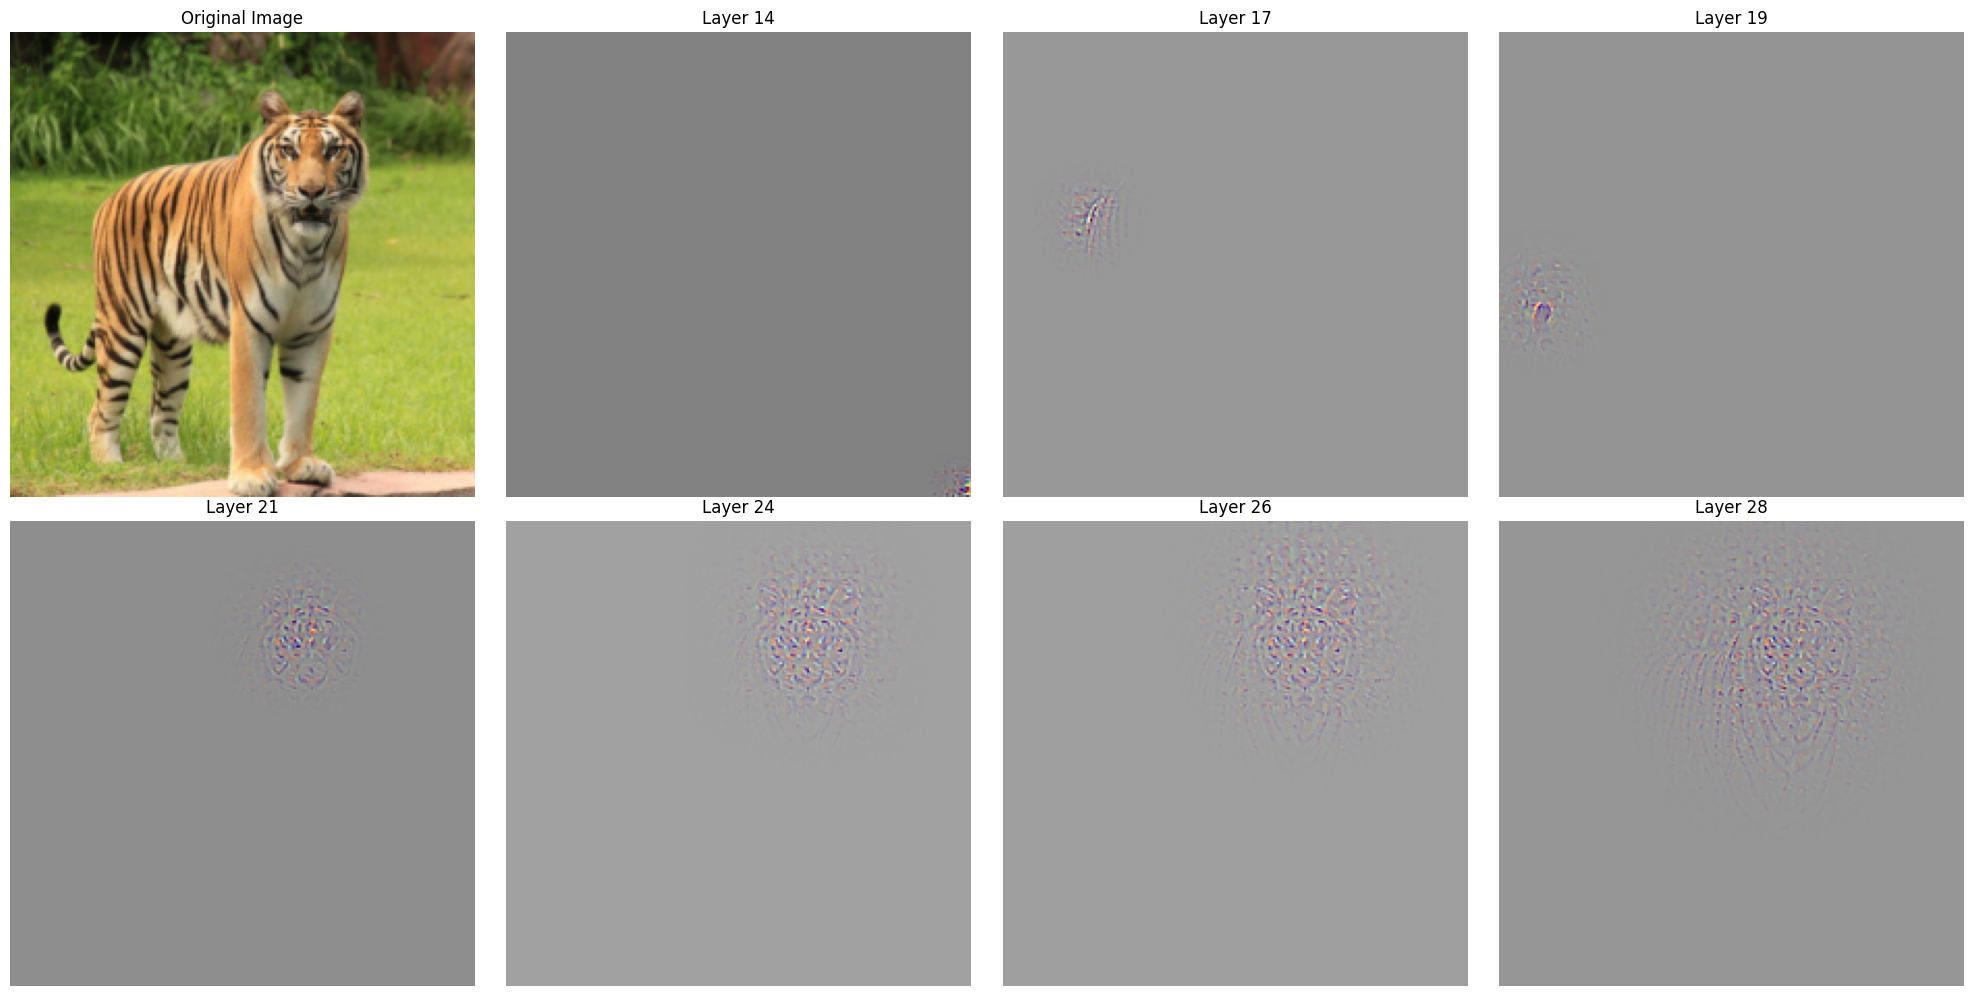

In [8]:
# === DeConvNet Visualization ===
vgg_conv = VGG16Conv().to(device).eval()
vgg_deconv = VGG16Deconv().to(device).eval()

_ = vgg_conv(input_tensor)  # Forward to record activations

# Layers to visualize (typically later conv layers in VGG)
layers_to_vis = [14, 17, 19, 21, 24, 26, 28]

plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
orig = denormalize(input_tensor).squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
plt.imshow(np.clip(orig, 0, 1))
plt.title("Original Image")
plt.axis('off')

for idx, layer in enumerate(layers_to_vis):
    recon_img = visualize_deconv_layer(layer, vgg_conv, vgg_deconv)
    plt.subplot(2, 4, idx+2)
    plt.imshow(recon_img)
    plt.title(f"Layer {layer}")
    plt.axis('off')

plt.tight_layout()
#plt.savefig('deconv_result.jpg')
#print("Deconv results saved to 'deconv_result.jpg'")